# **EXPERIEMENT-6** -Breast Cancer Dataset

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [17]:
from google.colab import drive
drive.mount('/content/drive')
df= pd.read_csv("/content/drive/MyDrive/Datasets/Breast_Cancer.csv")
print("\nFirst Two rows of the dataset:",df.head(2))
print("\nShape of the dataset:\n",df.shape)
print("\nColumns in the dataset:\n",df.columns)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

First Two rows of the dataset:    Age   Race Marital Status T Stage  N Stage 6th Stage  \
0   68  White        Married       T1      N1       IIA   
1   50  White        Married       T2      N2      IIIA   

               differentiate Grade   A Stage  Tumor Size Estrogen Status  \
0      Poorly differentiated     3  Regional           4        Positive   
1  Moderately differentiated     2  Regional          35        Positive   

  Progesterone Status  Regional Node Examined  Reginol Node Positive  \
0            Positive                      24                      1   
1            Positive                      14                      5   

   Survival Months Status  
0               60  Alive  
1               62  Alive  

Shape of the dataset:
 (4024, 16)

Columns in the dataset:
 Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th St

In [18]:
# Remove duplicates first
df = df.drop_duplicates()
# Clean Status properly
df['Status'] = df['Status'].astype(str)
df['Status'] = df['Status'].str.strip()
df['Status'] = df['Status'].str.lower()
print("Unique values after cleaning:", df['Status'].unique())
# Now map
df['Status'] = df['Status'].map({'alive':1, 'dead':0})
print("NaN count:", df['Status'].isna().sum())

Unique values after cleaning: ['alive' 'dead']
NaN count: 0


In [19]:
# Select ONLY 2 Numeric Features (for 2D visualization)
X = df[['Tumor Size', 'Survival Months']]
Y = df['Status']

In [20]:
# Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.3, stratify=Y, random_state=5)

In [21]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
# Manual Hyperparameter Tuning
C_values = [0.01, 0.1, 1, 10, 100]
penalties = ['l1', 'l2']
train_scores = np.zeros((len(penalties), len(C_values)))
test_scores = np.zeros((len(penalties), len(C_values)))

for i, p in enumerate(penalties):
    for j, C in enumerate(C_values):
        # Choose solver based on penalty
        if p == 'l1':
            solver_used = 'liblinear'
        else:
            solver_used = 'lbfgs'
        model = LogisticRegression(
            C=C,
            penalty=p,
            solver=solver_used,
            max_iter=1000,
            random_state=42
        )
        model.fit(X_train, Y_train)
        train_scores[i, j] = model.score(X_train, Y_train)
        test_scores[i, j] = model.score(X_test, Y_test)

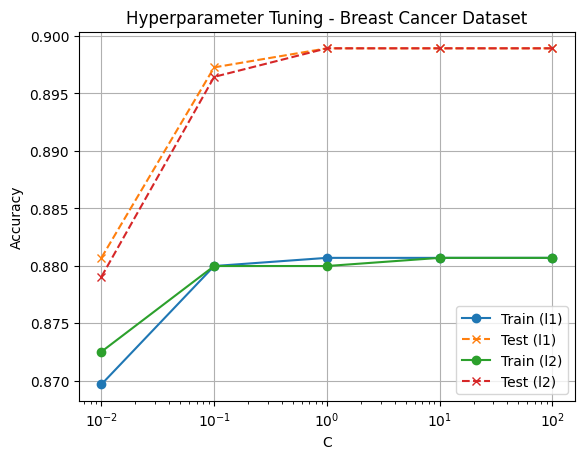

In [23]:
# Plot C vs Accuracy
plt.figure()

for i, p in enumerate(penalties):
    plt.plot(C_values, train_scores[i], marker='o', label=f'Train ({p})')
    plt.plot(C_values, test_scores[i], marker='x', linestyle='--', label=f'Test ({p})')

plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Hyperparameter Tuning - Breast Cancer Dataset")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# Select Best Parameters
best_idx = np.unravel_index(test_scores.argmax(), test_scores.shape)
best_penalty = penalties[best_idx[0]]
best_C = C_values[best_idx[1]]
# Select solver again for best penalty
if best_penalty == 'l1':
    best_solver = 'liblinear'
else:
    best_solver = 'lbfgs'
print("Best Penalty:", best_penalty)
print("Best C:", best_C)
print("Best Solver:", best_solver)

Best Penalty: l1
Best C: 1
Best Solver: liblinear


In [25]:
# Final Optimized Model
best_model = LogisticRegression(
    C=best_C,
    penalty=best_penalty,
    solver=best_solver,
    max_iter=1000,
    random_state=42
)
best_model.fit(X_train, Y_train)
Y_pred = best_model.predict(X_test)

In [26]:
# Evaluation
print("Final Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

Final Accuracy: 0.8989229494614748

Confusion Matrix:
 [[  80  105]
 [  17 1005]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.43      0.57       185
           1       0.91      0.98      0.94      1022

    accuracy                           0.90      1207
   macro avg       0.87      0.71      0.76      1207
weighted avg       0.89      0.90      0.89      1207



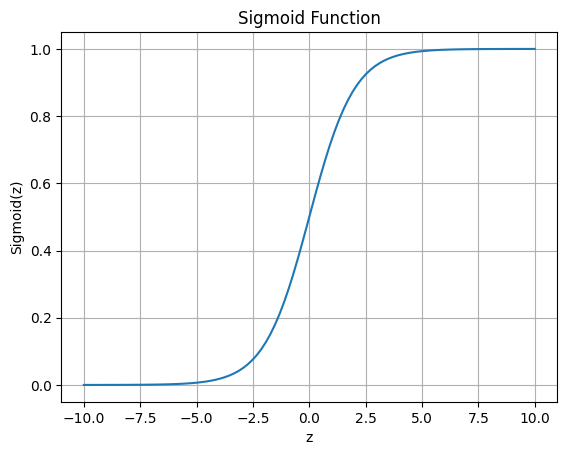

In [27]:
#  Sigmoid Function Visualization
z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure()
plt.plot(z, sigmoid)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.grid()
plt.show()


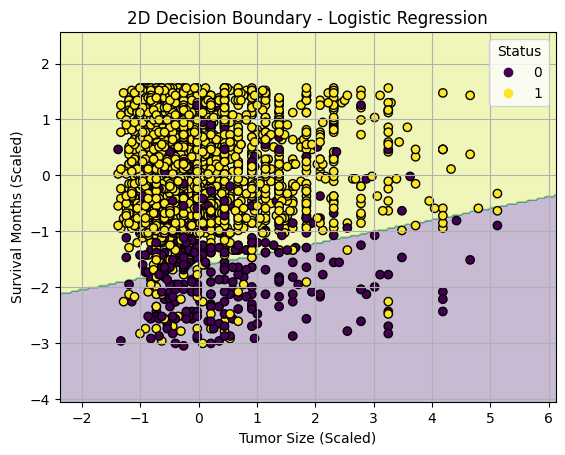

In [28]:

# 2D Decision Boundary
x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
scatter = plt.scatter(X_train[:,0], X_train[:,1], c=Y_train, edgecolor='k')

plt.xlabel("Tumor Size (Scaled)")
plt.ylabel("Survival Months (Scaled)")
plt.title("2D Decision Boundary - Logistic Regression")
plt.legend(*scatter.legend_elements(), title="Status")
plt.grid()
plt.show()